1. Install and Imports

In [1]:
! pip install mediapipe==0.10.21 opencv-contrib-python==4.10.0.84 numpy==1.26.4 scipy==1.13.1 matplotlib==3.8.4 protobuf==4.25.3 pandas -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sunil\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import cv2, mediapipe as mp, numpy as np, math, os, csv, time
import pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path
from IPython.display import display
print(cv2.__version__, mp.__version__, np.__version__)


4.11.0 0.10.9 1.26.4


 Config

In [3]:






datasetRoot   = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\0'
outputDir     = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles'

subjectIds    = None   # None = auto-discover, or e.g. ['01','02']
cameraNames   = None   # None = auto-discover, or e.g. ['cam0','cam1']
saveVideo     = False

modelComplexity   = 1
minDetectConf     = 0.4
minTrackConf      = 0.4
visibilityThresh  = 0.5
claheClip         = 2.5
claheGrid         = (8, 8)
savgolWindow      = 15
savgolOrder       = 3

os.makedirs(outputDir, exist_ok=True)

root = Path(datasetRoot)
if not root.exists():
    raise FileNotFoundError(f'Dataset root not found: {datasetRoot}')

if subjectIds is None:
    subjectIds = sorted([d.name for d in root.iterdir() if d.is_dir()])

videoFiles = {}
for sid in subjectIds:
    subjDir = root / sid
    if not subjDir.exists():
        print(f'[WARN] subject {sid}: folder not found, skipping'); continue
    mp4s = sorted(subjDir.glob('*.mp4'))
    if not mp4s:
        print(f'[WARN] subject {sid}: no .mp4 files found, skipping'); continue
    for mp4 in mp4s:
        cam = mp4.stem
        if cameraNames is None or cam in cameraNames:
            videoFiles[(sid, cam)] = str(mp4)

print(f'Subjects: {len(subjectIds)}  |  Videos queued: {len(videoFiles)}')

Subjects: 16  |  Videos queued: 80


Helpers

In [4]:
mpPose = mp.solutions.pose
_clahe = cv2.createCLAHE(clipLimit=claheClip, tileGridSize=claheGrid)

def enhanceFrame(frame):
    l, a, b = cv2.split(cv2.cvtColor(frame, cv2.COLOR_BGR2LAB))
    return cv2.cvtColor(cv2.merge([_clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

def angle(a, b, c):
    ba = np.array([a[0]-b[0], a[1]-b[1]], dtype=float)
    bc = np.array([c[0]-b[0], c[1]-b[1]], dtype=float)
    n = np.linalg.norm(ba) * np.linalg.norm(bc)
    return math.degrees(math.acos(np.clip(np.dot(ba,bc)/n,-1,1))) if n else 0.0

def lmPx(lm, idx, w, h):
    p = lm[idx]
    return (int(p.x*w), int(p.y*h)) if p.visibility >= visibilityThresh else None

def viewMode(lm):
    return 'side' if abs(lm[23].x - lm[24].x) < 0.06 else 'front'

def drawSkeleton(frame, lm, angles, w, h):
    for s,e in [(23,25),(25,27),(24,26),(26,28),(23,24)]:
        ps,pe = lm[s],lm[e]
        if ps.visibility>=visibilityThresh and pe.visibility>=visibilityThresh:
            cv2.line(frame,(int(ps.x*w),int(ps.y*h)),(int(pe.x*w),int(pe.y*h)),(255,165,0),3,cv2.LINE_AA)
    for i in range(23,33):
        p=lm[i]
        if p.visibility>=visibilityThresh:
            cv2.circle(frame,(int(p.x*w),int(p.y*h)),7,(0,255,0),-1,cv2.LINE_AA)
    for i,lbl,key,col in [(25,'LK','L_knee',(100,255,100)),(26,'RK','R_knee',(100,255,100)),
                           (23,'LH','L_hip',(255,200,100)),(24,'RH','R_hip',(255,200,100)),
                           (27,'LA','L_ankle',(200,100,255)),(28,'RA','R_ankle',(200,100,255))]:
        p=lm[i]; v=angles.get(key)
        if p.visibility>=visibilityThresh and v is not None:
            cv2.putText(frame,f'{lbl}:{v:.0f}',(int(p.x*w)+12,int(p.y*h)-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.55,col,2,cv2.LINE_AA)

csvFields = ['subject','camera','frame','timestampMs','timeS','viewMode','detection',
             'L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle',
             'vis_LK','vis_RK','vis_LA','vis_RA','vis_LH','vis_RH']

print('Helpers ready')

Helpers ready


 Process All Videos

In [5]:
allDfs   = []
skipped  = []
total    = len(videoFiles)

with mpPose.Pose(static_image_mode=False, model_complexity=modelComplexity,
                 smooth_landmarks=True, min_detection_confidence=minDetectConf,
                 min_tracking_confidence=minTrackConf) as pose:

    for idx, ((sid, cam), vidPath) in enumerate(videoFiles.items(), 1):
        if not os.path.exists(vidPath):
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: file not found')
            skipped.append((sid, cam, 'file not found'))
            continue

        cap = cv2.VideoCapture(vidPath)
        if not cap.isOpened():
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: cannot open video')
            skipped.append((sid, cam, 'cannot open'))
            continue

        fpsVid  = cap.get(cv2.CAP_PROP_FPS) or 30.0
        totalF  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        vidW    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        vidH    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        subjOut = os.path.join(outputDir, f'subject_{sid}')
        os.makedirs(subjOut, exist_ok=True)

        writer = None
        if saveVideo:
            writer = cv2.VideoWriter(os.path.join(subjOut, f'{cam}_annotated.mp4'),
                                     cv2.VideoWriter_fourcc(*'mp4v'), 30, (vidW, vidH))

        rows, detected, frameIdx, t0 = [], 0, 0, time.time()

        while True:
            ok, frame = cap.read()
            if not ok: break
            frameIdx += 1
            h, w = frame.shape[:2]

            rgb = cv2.cvtColor(enhanceFrame(frame), cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            res = pose.process(rgb)

            row = {'subject':sid,'camera':cam,'frame':frameIdx,
                   'timestampMs':round(frameIdx/fpsVid*1000,1),
                   'timeS':round(frameIdx/fpsVid,4),
                   'viewMode':'N/A','detection':0,
                   'L_knee':None,'R_knee':None,'L_hip':None,'R_hip':None,
                   'L_ankle':None,'R_ankle':None,
                   'vis_LK':None,'vis_RK':None,'vis_LA':None,
                   'vis_RA':None,'vis_LH':None,'vis_RH':None}

            if res.pose_landmarks:
                detected += 1
                lm = res.pose_landmarks.landmark
                row.update({'detection':1,'viewMode':viewMode(lm),
                            'vis_LK':round(lm[25].visibility,3),'vis_RK':round(lm[26].visibility,3),
                            'vis_LA':round(lm[27].visibility,3),'vis_RA':round(lm[28].visibility,3),
                            'vis_LH':round(lm[23].visibility,3),'vis_RH':round(lm[24].visibility,3)})

                LH=lmPx(lm,23,w,h);RH=lmPx(lm,24,w,h);LK=lmPx(lm,25,w,h)
                RK=lmPx(lm,26,w,h);LA=lmPx(lm,27,w,h);RA=lmPx(lm,28,w,h)
                LS=lmPx(lm,11,w,h);RS=lmPx(lm,12,w,h)
                LFI=lmPx(lm,31,w,h);RFI=lmPx(lm,32,w,h)

                ang = {}
                if all([LH,LK,LA]):  ang['L_knee']  = row['L_knee']  = round(angle(LH,LK,LA),2)
                if all([RH,RK,RA]):  ang['R_knee']  = row['R_knee']  = round(angle(RH,RK,RA),2)
                if all([LS,LH,LK]):  ang['L_hip']   = row['L_hip']   = round(angle(LS,LH,LK),2)
                if all([RS,RH,RK]):  ang['R_hip']   = row['R_hip']   = round(angle(RS,RH,RK),2)
                if all([LK,LA,LFI]): ang['L_ankle'] = row['L_ankle'] = round(angle(LK,LA,LFI),2)
                if all([RK,RA,RFI]): ang['R_ankle'] = row['R_ankle'] = round(angle(RK,RA,RFI),2)

                if writer: drawSkeleton(frame, lm, ang, w, h)

            if writer: writer.write(frame)
            rows.append(row)

        cap.release()
        if writer: writer.release()

        if frameIdx == 0:
            print(f'[WARN {idx:>3}/{total}] subject={sid} {cam}: 0 frames read')
            skipped.append((sid, cam, '0 frames read'))
            continue

        dfCam = pd.DataFrame(rows, columns=csvFields)
        dfCam.to_csv(os.path.join(subjOut, f'{cam}_angles.csv'), index=False)
        allDfs.append(dfCam)

        print(f'[{idx:>3}/{total}] s={sid} {cam}  {frameIdx}fr  '
              f'det={100*detected/frameIdx:.0f}%  {time.time()-t0:.1f}s')

if allDfs:
    merged = pd.concat(allDfs, ignore_index=True)
    merged.to_csv(os.path.join(outputDir,'ALL_subjects_angles.csv'), index=False)
    print(f'\nMerged CSV: {len(merged)} rows')

if skipped:
    print(f'\nSkipped ({len(skipped)}):')
    for s in skipped: print(f'  subject={s[0]} {s[1]}: {s[2]}')

print('Done.')

[  1/80] s=01 cam0  630fr  det=100%  51.8s
[  2/80] s=01 cam1  630fr  det=100%  50.4s
[  3/80] s=01 cam2  630fr  det=100%  59.2s
[  4/80] s=01 cam3  630fr  det=100%  59.3s
[  5/80] s=01 cam4  630fr  det=100%  60.2s
[  6/80] s=02 cam0  917fr  det=100%  87.7s
[  7/80] s=02 cam1  917fr  det=100%  92.2s
[  8/80] s=02 cam2  917fr  det=100%  88.0s
[  9/80] s=02 cam3  917fr  det=100%  105.1s
[ 10/80] s=02 cam4  916fr  det=100%  101.2s
[ 11/80] s=03 cam0  794fr  det=94%  95.5s
[ 12/80] s=03 cam1  794fr  det=100%  92.0s
[ 13/80] s=03 cam2  794fr  det=100%  88.8s
[ 14/80] s=03 cam3  794fr  det=100%  81.6s
[ 15/80] s=03 cam4  794fr  det=100%  85.1s
[ 16/80] s=04 cam0  1146fr  det=100%  121.1s
[ 17/80] s=04 cam1  1146fr  det=100%  117.5s
[ 18/80] s=04 cam2  1146fr  det=100%  115.4s
[ 19/80] s=04 cam3  1146fr  det=100%  113.5s
[ 20/80] s=04 cam4  1146fr  det=100%  115.0s
[ 21/80] s=05 cam0  687fr  det=100%  68.9s
[ 22/80] s=05 cam1  687fr  det=100%  68.5s
[ 23/80] s=05 cam2  687fr  det=100%  69.9s


C:\Users\sunil\AppData\Local\Temp\ipykernel_20604\4260933336.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(allDfs, ignore_index=True)



Merged CSV: 55070 rows
Done.


Sample Frames

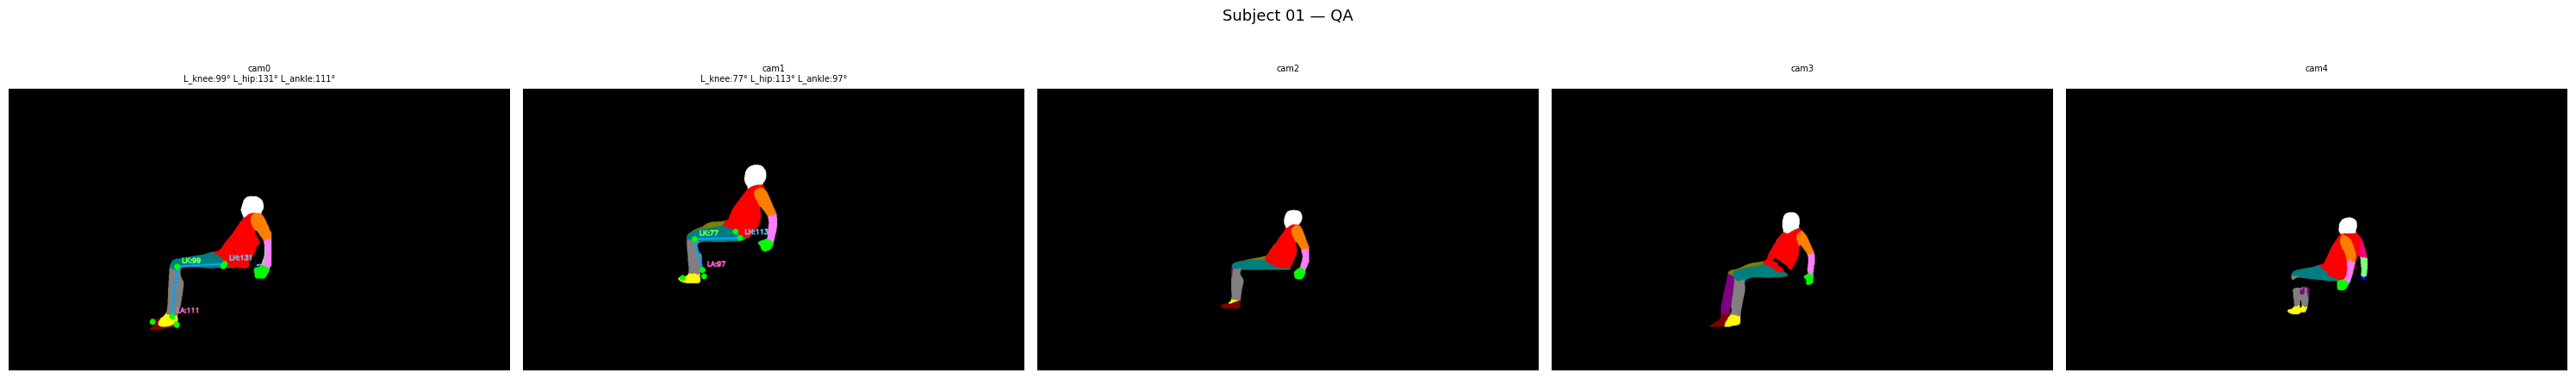

In [6]:
sidQa   = subjectIds[0]
camsQa  = [(s,c) for (s,c) in videoFiles if s == sidQa]
n       = len(camsQa)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1: axes = [axes]
fig.suptitle(f'Subject {sidQa} — QA', fontsize=13)

with mpPose.Pose(static_image_mode=True, model_complexity=modelComplexity,
                 min_detection_confidence=minDetectConf) as poseS:
    for ax, (sid, cam) in zip(axes, camsQa):
        cap = cv2.VideoCapture(videoFiles[(sid,cam)])
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(cap.get(cv2.CAP_PROP_FRAME_COUNT))//2)
        ok, frame = cap.read(); cap.release()
        if not ok: ax.set_title(f'{cam}: error'); ax.axis('off'); continue
        h,w = frame.shape[:2]
        res = poseS.process(cv2.cvtColor(enhanceFrame(frame), cv2.COLOR_BGR2RGB))
        ang = {}
        if res.pose_landmarks:
            lm = res.pose_landmarks.landmark
            def _p(i): p=lm[i]; return (int(p.x*w),int(p.y*h)) if p.visibility>=visibilityThresh else None
            LH,RH,LK,RK,LA,RA=_p(23),_p(24),_p(25),_p(26),_p(27),_p(28)
            LS,RS,LFI,RFI=_p(11),_p(12),_p(31),_p(32)
            if all([LH,LK,LA]):  ang['L_knee'] =angle(LH,LK,LA)
            if all([RH,RK,RA]):  ang['R_knee'] =angle(RH,RK,RA)
            if all([LS,LH,LK]):  ang['L_hip']  =angle(LS,LH,LK)
            if all([RS,RH,RK]):  ang['R_hip']  =angle(RS,RH,RK)
            if all([LK,LA,LFI]): ang['L_ankle']=angle(LK,LA,LFI)
            if all([RK,RA,RFI]): ang['R_ankle']=angle(RK,RA,RFI)
            drawSkeleton(frame, lm, ang, w, h)
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(cam+'\n'+' '.join(f'{k}:{v:.0f}°' for k,v in ang.items()), fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(outputDir,f'qa_{sidQa}.png'), dpi=120, bbox_inches='tight')
plt.show()

TimeSeries 

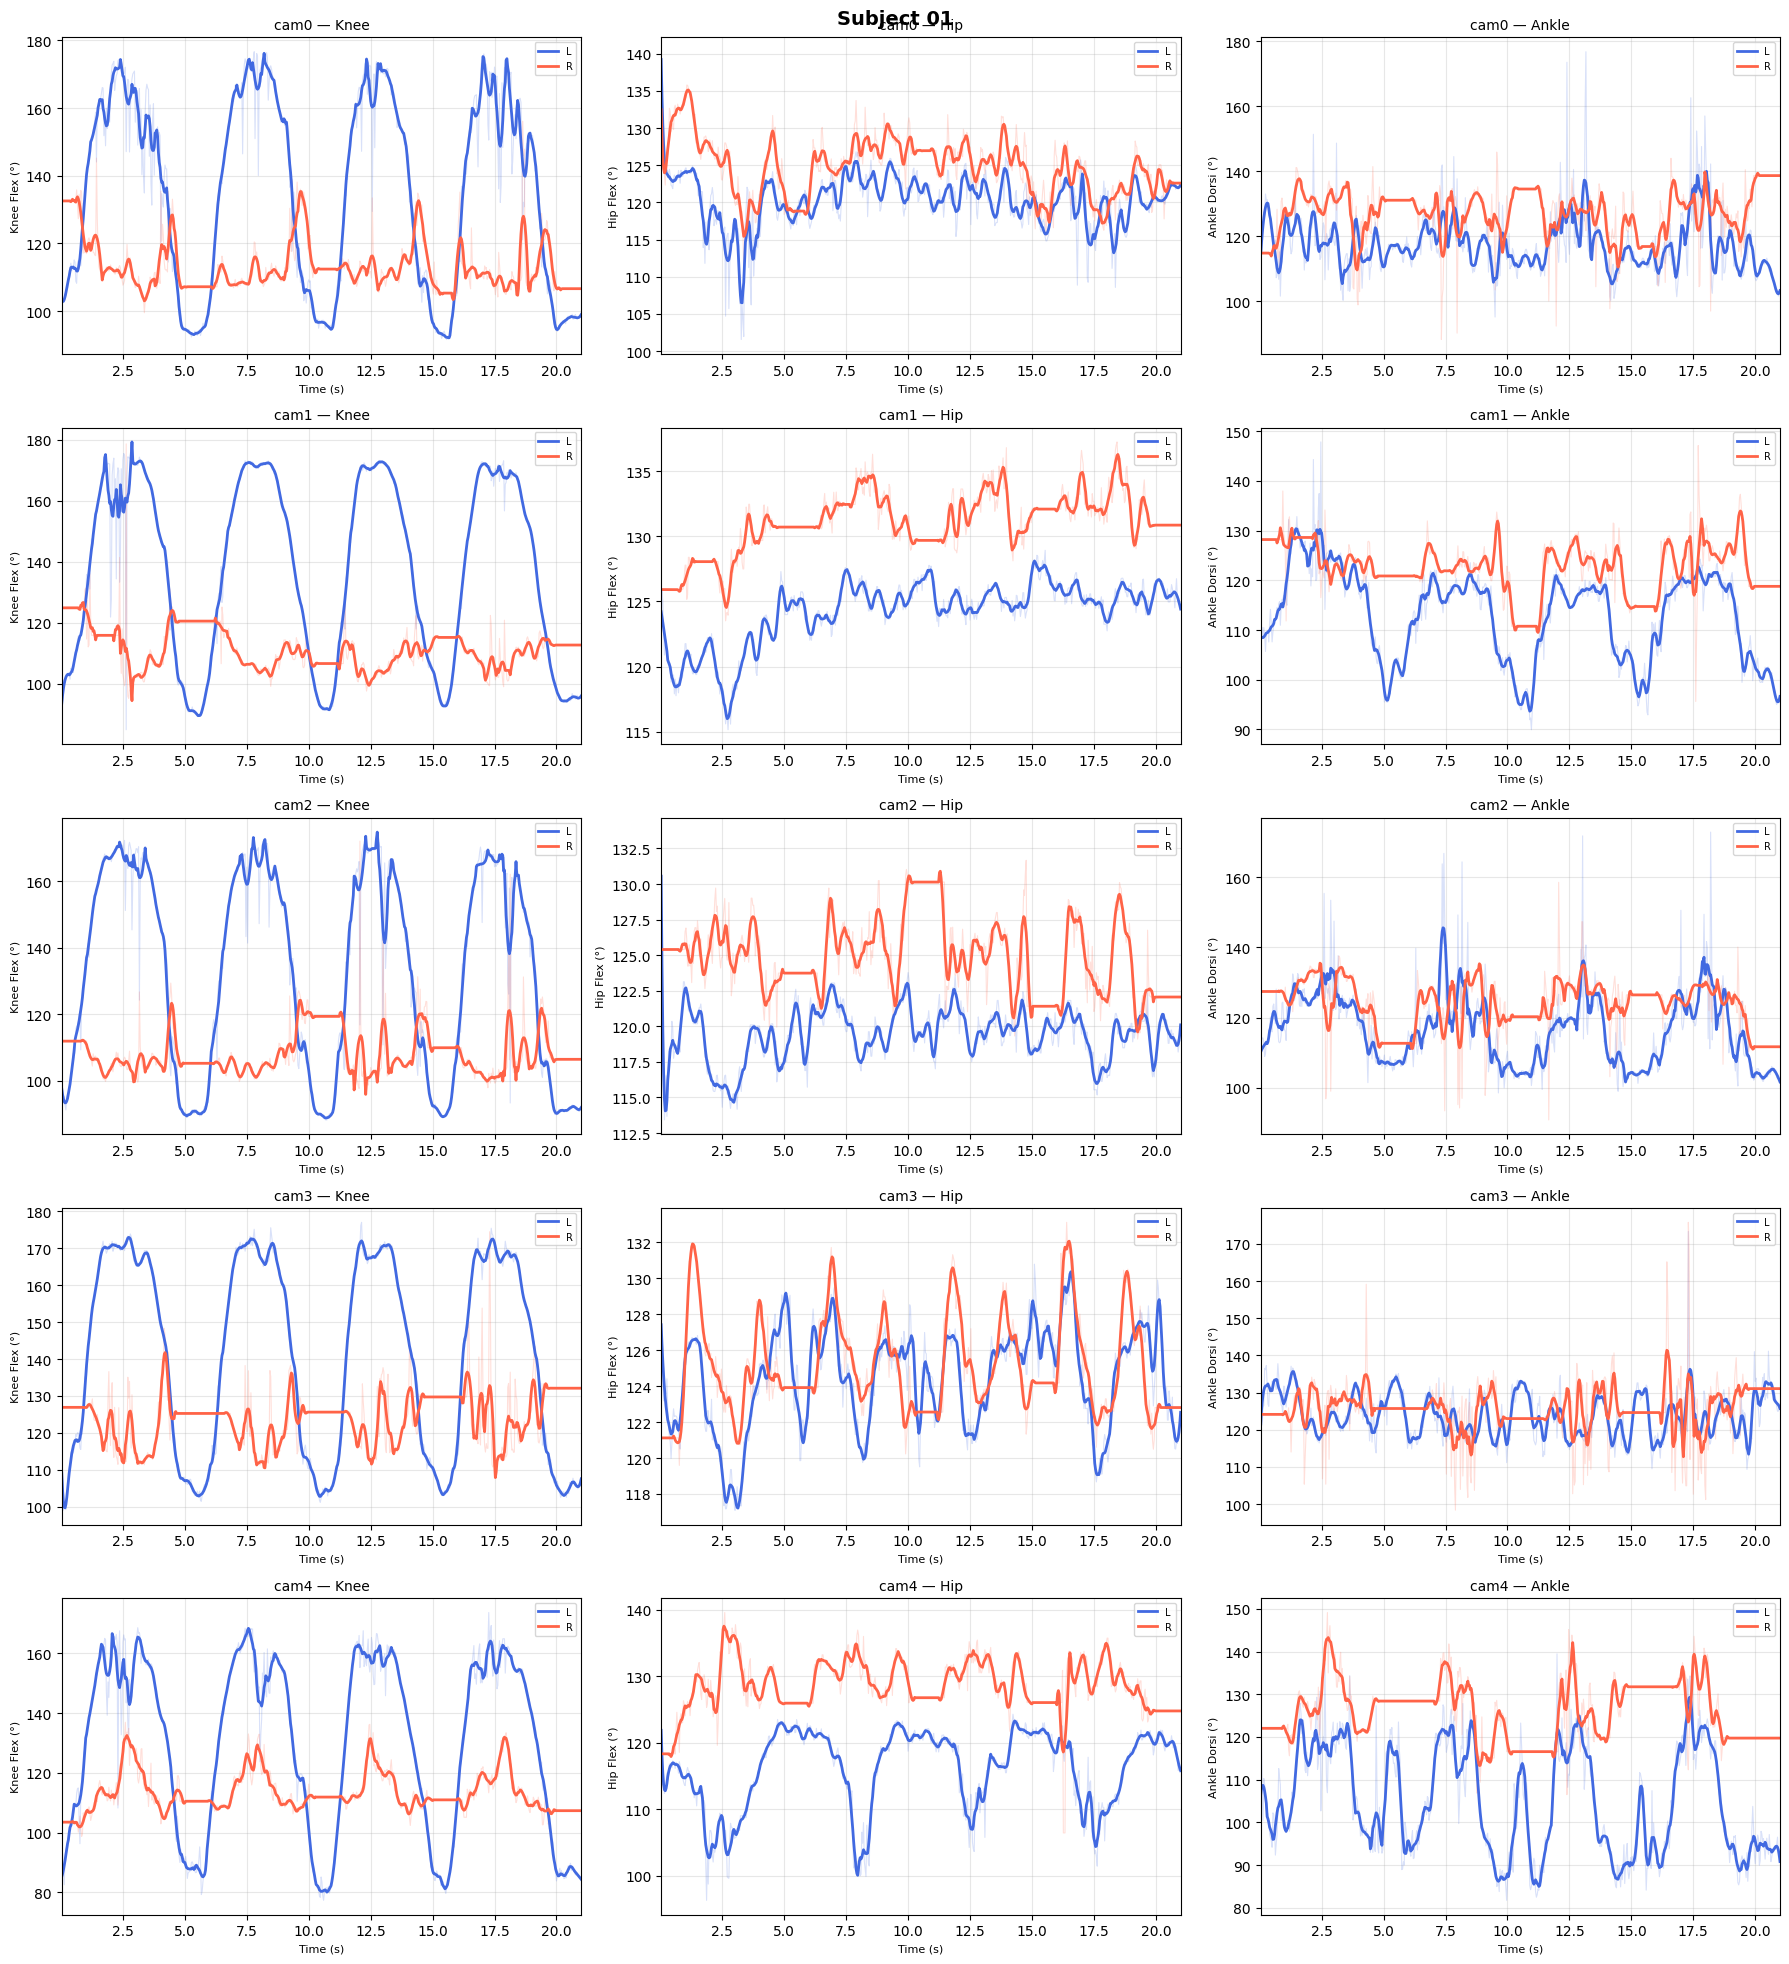

In [7]:
sidPlot  = subjectIds[0]   # change to inspect another subject
dfsSubj  = [df for df in allDfs if df['subject'].iloc[0] == sidPlot]
aPairs   = [('L_knee','R_knee','Knee Flex (°)'),
             ('L_hip','R_hip','Hip Flex (°)'),
             ('L_ankle','R_ankle','Ankle Dorsi (°)')]
nC       = len(dfsSubj)
fig, axes = plt.subplots(nC, 3, figsize=(18, 4*nC))
if nC == 1: axes = [axes]
fig.suptitle(f'Subject {sidPlot}', fontsize=14, fontweight='bold')

for ri, df in enumerate(dfsSubj):
    t = df['timeS']
    for ci, (lc,rc,yl) in enumerate(aPairs):
        ax = axes[ri][ci]
        lr = df[lc].ffill().bfill(); rr = df[rc].ffill().bfill()
        ls = savgol_filter(lr,savgolWindow,savgolOrder) if len(lr)>=savgolWindow else lr.values
        rs = savgol_filter(rr,savgolWindow,savgolOrder) if len(rr)>=savgolWindow else rr.values
        ax.plot(t,lr,alpha=0.2,color='royalblue',lw=0.8)
        ax.plot(t,rr,alpha=0.2,color='tomato',lw=0.8)
        ax.plot(t,ls,color='royalblue',lw=2,label='L')
        ax.plot(t,rs,color='tomato',lw=2,label='R')
        ax.set_title(f"{df['camera'].iloc[0]} — {yl.split(' ')[0]}",fontsize=10)
        ax.set_xlabel('Time (s)',fontsize=8); ax.set_ylabel(yl,fontsize=8)
        ax.legend(fontsize=7); ax.grid(True,alpha=0.3); ax.set_xlim(t.min(),t.max())

plt.tight_layout()
plt.savefig(os.path.join(outputDir,f'ts_{sidPlot}.png'),dpi=130,bbox_inches='tight')
plt.show()

## 8. ROM Summary

In [8]:
aCols = ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']
rows  = []
for df in allDfs:
    r = {'subject':df['subject'].iloc[0],'camera':df['camera'].iloc[0],
         'det_%':f"{100*df['detection'].mean():.1f}",'frames':len(df)}
    for c in aCols:
        s = df[c].dropna()
        r[f'{c}_mean'] = f'{s.mean():.1f}' if len(s) else 'N/A'
        r[f'{c}_ROM']  = f'{s.max()-s.min():.1f}' if len(s) else 'N/A'
    rows.append(r)
dfSummary = pd.DataFrame(rows)
dfSummary.to_csv(os.path.join(outputDir,'rom_summary.csv'), index=False)
display(dfSummary.head(20))

,subject,camera,det_%,frames,L_knee_mean,L_knee_ROM,R_knee_mean,R_knee_ROM,L_hip_mean,L_hip_ROM,R_hip_mean,R_hip_ROM,L_ankle_mean,L_ankle_ROM,R_ankle_mean,R_ankle_ROM
0,01,cam0,100.0,630,135.8,85.1,114.0,56.6,120.3,38.7,124.9,25.8,117.4,81.7,126.5,57.7
1,01,cam1,100.0,630,137.7,90.6,109.3,83.5,124.2,13.8,131.7,13.7,113.0,57.9,124.1,51.5
2,01,cam2,100.0,630,133.1,84.3,107.1,74.6,119.4,20.2,125.0,12.6,116.6,74.4,125.5,67.8
3,01,cam3,100.0,630,141.2,77.9,121.6,63.7,124.5,14.1,125.8,13.5,123.9,64.0,125.8,77.4
4,01,cam4,100.0,630,130.1,96.3,114.7,38.2,116.1,28.0,129.9,33.1,104.9,57.7,128.9,42.6
5,02,cam0,99.9,917,136.0,99.1,132.6,61.1,127.2,115.7,129.8,15.9,116.0,59.6,115.5,30.5
6,02,cam1,100.0,917,133.9,89.9,125.3,62.0,130.2,18.6,133.5,15.7,109.6,40.6,117.7,25.3
7,02,cam2,100.0,917,131.8,93.1,130.5,39.6,123.6,28.1,129.9,10.6,112.3,50.9,117.6,29.1
8,02,cam3,100.0,917,135.3,84.5,150.9,65.8,125.7,16.0,122.7,22.0,119.8,47.2,120.0,40.5
9,02,cam4,100.0,916,133.5,93.1,N/A,N/A,119.1,25.8,115.4,8.2,105.9,113.5,N/A,N/A


## 9. Download (Colab)

In [9]:
import zipfile
zipPath = outputDir + '.zip'
with zipfile.ZipFile(zipPath,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in Path(outputDir).rglob('*'):
        zf.write(f, f.relative_to(outputDir))
print(f'Zip: {zipPath}  ({os.path.getsize(zipPath)//1024} KB)')
try:
    from google.colab import files; files.download(zipPath)
except ImportError:
    print('Not in Colab — files at:', os.path.abspath(outputDir))

Zip: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles.zip  (4108 KB)
Not in Colab — files at: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles
